# TFT Stock Return Prediction

In [ ]:
# import subprocess, sys
# from pathlib import Path

# requirements_candidates = [Path('../requirements.txt'), Path('requirements.txt'), Path('../../backend/requirements.txt')]
# REQUIREMENTS_FILE = next(
#     candidate.resolve()
#     for candidate in requirements_candidates
#     if candidate.exists()
# )
# print(f'Installing packages from {REQUIREMENTS_FILE}')
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REQUIREMENTS_FILE), '-q'])
# print('Done!')

## Run this is import fails


In [146]:
import pandas as pd
import numpy as np
import json
import warnings
from pathlib import Path
from datetime import datetime, timezone
import torch
import plotly.graph_objects as go
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display


In [147]:
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

In [148]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TRAINER_ACCELERATOR = 'gpu' if DEVICE.type == 'cuda' else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cpu


In [177]:
RETRAIN = True
MODEL_VERSION = None

# Training and model configuration
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 25
LEARNING_RATE = 0.0001
HIDDEN_SIZE = 128
ATTENTION_HEAD_SIZE = 2
HIDDEN_CONTINUOUS_SIZE = 32
DROPOUT = 0.01
REDUCE_ON_PLATEAU_PATIENCE = 5
EARLY_STOPPING_PATIENCE = 5
GRADIENT_CLIP_VAL = 0.005   # 0.005
ENCODER_LENGTH = 6
PREDICTION_LENGTH = 1  # Forecast horizon (fixed at 1 month)

# Dynamic time split configuration (in months)
# The dataset will be split from the end backwards:
# - Last TEST_LENGTH_MONTHS months → test set
# - Preceding VALIDATION_LENGTH_MONTHS months → validation set
# - All remaining earlier data → training set
VALIDATION_LENGTH_MONTHS =6
TEST_LENGTH_MONTHS = 6

In [178]:
REPO = Path('../../').resolve()
CSV_RAW = REPO / 'data/processed/final/stock_macro_monthly_target.csv'
CSV_MODEL = REPO / 'data/processed/final/stock_macro_monthly_model.csv'
MODEL_ROOT = REPO / 'backend/models/tft'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

version_dirs = sorted(
    [
        path for path in MODEL_ROOT.glob('v*')
        if path.is_dir() and path.name[1:].isdigit()
    ],
    key=lambda path: int(path.name[1:]),
)
available_versions = [int(path.name[1:]) for path in version_dirs]

if RETRAIN:
    MODEL_VERSION = (max(available_versions) + 1) if available_versions else 1
elif MODEL_VERSION is None:
    if available_versions:
        MODEL_VERSION = max(available_versions)
    else:
        raise FileNotFoundError(
            f'No saved model versions found under {MODEL_ROOT}. Set RETRAIN = True first.'
        )
elif MODEL_VERSION not in available_versions:
    raise FileNotFoundError(
        f'Model version v{MODEL_VERSION} was not found under {MODEL_ROOT}. '
        f'Available versions: {available_versions}'
    )

MODEL_DIR = MODEL_ROOT / f'v{MODEL_VERSION}'

MODEL_PATH = MODEL_DIR / 'tft_model.pt'
LOSS_HISTORY_PATH = MODEL_DIR / 'loss_history.json'
MODEL_METADATA_PATH = MODEL_DIR / 'model_metadata.json'
CHECKPOINT_DIR = MODEL_ROOT / '_checkpoints'

print(f'Available model versions: {available_versions or "none"}')
print(f'Using model version: v{MODEL_VERSION}')
print(f'Retrain enabled: {RETRAIN}')

Available model versions: [2, 3, 4, 5, 6, 7, 8, 9]
Using model version: v10
Retrain enabled: True


In [179]:
df = pd.read_csv(CSV_RAW)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['isin', 'date']).reset_index(drop=True)
print(f'Loaded: {df.shape[0]} rows, {df["isin"].nunique()} stocks')

Loaded: 60846 rows, 437 stocks


In [180]:
# Calculate dynamic split dates based on configuration
max_date = df['date'].max()
min_date = df['date'].min()
total_months = (max_date.year - min_date.year) * 12 + (max_date.month - min_date.month)

print(f'Data date range: {min_date} to {max_date}')
print(f'Total available months: {total_months}')

# Minimum months required, per split, for the resulting dataframes to be
# leakage-free once the ENCODER_LENGTH-month lookback is added (see the
# train/val/test split cell below):
# - VALIDATION_LENGTH_MONTHS must be >= ENCODER_LENGTH, otherwise test's
#   encoder lookback (test_start - ENCODER_LENGTH) reaches past val_start and
#   directly overlaps raw rows with train (skipping over val entirely).
# - TEST_LENGTH_MONTHS only needs >= PREDICTION_LENGTH, since nothing follows
#   test and its own encoder lookback is only ever expected to reach into val.
VALIDATION_MIN_MONTHS = ENCODER_LENGTH
TEST_MIN_MONTHS = PREDICTION_LENGTH

# Validate that we have enough data for the requested splits
requested_months = VALIDATION_LENGTH_MONTHS + TEST_LENGTH_MONTHS
if requested_months > total_months:
    print(f'Warning: Requested {requested_months} months for validation+test exceeds available {total_months} months.')
    print(f'Reducing validation and test lengths proportionally to fit available data.')
    # Reduce proportionally to fit
    ratio = total_months / requested_months
    VALIDATION_LENGTH_MONTHS = int(VALIDATION_LENGTH_MONTHS * ratio)
    TEST_LENGTH_MONTHS = int(TEST_LENGTH_MONTHS * ratio)
    # Ensure each split still meets its own minimum
    VALIDATION_LENGTH_MONTHS = max(VALIDATION_MIN_MONTHS, VALIDATION_LENGTH_MONTHS)
    TEST_LENGTH_MONTHS = max(TEST_MIN_MONTHS, TEST_LENGTH_MONTHS)
    print(f'Adjusted lengths - Validation: {VALIDATION_LENGTH_MONTHS} months, Test: {TEST_LENGTH_MONTHS} months')

# Also ensure each split meets its own minimum requirement
if VALIDATION_LENGTH_MONTHS < VALIDATION_MIN_MONTHS:
    print(f'Warning: VALIDATION_LENGTH_MONTHS ({VALIDATION_LENGTH_MONTHS}) < minimum required ({VALIDATION_MIN_MONTHS}). Adjusting to {VALIDATION_MIN_MONTHS}.')
    VALIDATION_LENGTH_MONTHS = VALIDATION_MIN_MONTHS
if TEST_LENGTH_MONTHS < TEST_MIN_MONTHS:
    print(f'Warning: TEST_LENGTH_MONTHS ({TEST_LENGTH_MONTHS}) < minimum required ({TEST_MIN_MONTHS}). Adjusting to {TEST_MIN_MONTHS}.')
    TEST_LENGTH_MONTHS = TEST_MIN_MONTHS

# Calculate split dates
test_start = max_date - pd.DateOffset(months=TEST_LENGTH_MONTHS)
val_start = test_start - pd.DateOffset(months=VALIDATION_LENGTH_MONTHS)

print(f'Validation start date: {val_start}')
print(f'Test start date: {test_start}')
print(f'Train period: {min_date} to {val_start}')
print(f'Validation period: {val_start} to {test_start}')
print(f'Test period: {test_start} to {max_date}')

Data date range: 2010-01-01 00:00:00 to 2026-09-01 00:00:00
Total available months: 200
Validation start date: 2025-09-01 00:00:00
Test start date: 2026-03-01 00:00:00
Train period: 2010-01-01 00:00:00 to 2025-09-01 00:00:00
Validation period: 2025-09-01 00:00:00 to 2026-03-01 00:00:00
Test period: 2026-03-01 00:00:00 to 2026-09-01 00:00:00


In [181]:
# Calculate returns and target
df['stock_return_1m'] = df.groupby('isin')['monthly_open'].pct_change() * 100
df['target_return_1m'] = df.groupby('isin')['stock_return_1m'].shift(-1)
df = df.dropna(subset=['stock_return_1m', 'target_return_1m']).reset_index(drop=True)
print(f'After dropna: {df.shape[0]} rows')

After dropna: 59972 rows


In [182]:
# Add stock-specific technical features
g = df.groupby('isin')['stock_return_1m']
df['momentum_3m'] = g.transform(lambda s: s.rolling(3, min_periods=1).sum()).fillna(0).clip(-500, 500)
df['momentum_6m'] = g.transform(lambda s: s.rolling(6, min_periods=1).sum()).fillna(0).clip(-500, 500)
df['momentum_12m'] = g.transform(lambda s: s.rolling(12, min_periods=1).sum()).fillna(0).clip(-500, 500)
df['volatility_3m'] = g.transform(lambda s: s.rolling(3, min_periods=2).std()).fillna(0).clip(0, 200)
df['volatility_6m'] = g.transform(lambda s: s.rolling(6, min_periods=2).std()).fillna(0).clip(0, 200)
df['volume_change_1m'] = df.groupby('isin')['monthly_volume'].transform(lambda s: s.pct_change() * 100).fillna(0).clip(-500, 500)

print('Added technical features')

Added technical features


In [183]:
# Select features. real_features never contain missing/infinite values in
# this dataset (verified upstream). nan_label_features (oil/gold return %s
# and CPI columns) do contain NaNs early in the date range - rather than
# imputing a fabricated value (e.g. a median), they are kept as raw values
# and modeled as categoricals via pytorch_forecasting's NaNLabelEncoder (see
# TimeSeriesDataSet construction below), which treats NaN as its own explicit
# category instead of guessing a numeric fill.
real_features = ['monthly_volume', 'oil_price_usd_bbl', 'gold_price_inr_10g',
                  'stock_return_1m', 'momentum_3m', 'momentum_6m', 'momentum_12m',
                  'volatility_3m', 'volatility_6m', 'volume_change_1m']
nan_label_features = ['oil_return_1m_pct', 'oil_return_12m_pct',
                       'gold_return_1m_pct', 'gold_return_12m_pct',
                       'cpi_index', 'cpi_inflation_yoy_pct']
features = real_features + nan_label_features

df = df[['isin', 'symbol', 'date'] + features + ['target_return_1m']].copy()

# NaNLabelEncoder requires a non-numeric (string) column, and its NaN category
# key is the literal string 'nan' for non-numeric dtypes - so missing values
# must be converted to that literal string, not left as float NaN (pandas'
# default .astype(str) preserves float NaN as a true missing value rather
# than stringifying it, which would not match the encoder's expected key).
for col in nan_label_features:
    df[col] = df[col].map(lambda v: 'nan' if pd.isna(v) else str(v))

print('No numeric imputation applied - NaNs in nan_label_features are handled by NaNLabelEncoder downstream')


No numeric imputation applied - NaNs in nan_label_features are handled by NaNLabelEncoder downstream


In [184]:
# Temporal split (dynamic based on VALIDATION_LENGTH_MONTHS and TEST_LENGTH_MONTHS)
# IMPORTANT: val and test must include ENCODER_LENGTH months of history before their start dates
# so that TimeSeriesDataSet can create sequences with the full encoder window
train = df[df['date'] < val_start].copy()
val = df[(df['date'] >= val_start - pd.DateOffset(months=ENCODER_LENGTH)) & (df['date'] < test_start)].copy()
test = df[df['date'] >= test_start - pd.DateOffset(months=ENCODER_LENGTH)].copy()

print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')
print(f'Train date range: {train["date"].min()} to {train["date"].max()}')
print(f'Val date range:   {val["date"].min()} to {val["date"].max()}')
print(f'Test date range:  {test["date"].min()} to {test["date"].max()}')

Train: 54957, Val: 4829, Test: 5015
Train date range: 2010-02-01 00:00:00 to 2025-08-01 00:00:00
Val date range:   2025-03-01 00:00:00 to 2026-02-01 00:00:00
Test date range:  2025-09-01 00:00:00 to 2026-08-01 00:00:00


In [185]:
# Create time_idx and series_id
min_date = df['date'].min()
max_date = df['date'].max()

df['time_idx'] = (
    (df['date'].dt.year - min_date.year) * 12
    + (df['date'].dt.month - min_date.month)
)

all_isins_sorted = sorted(df['isin'].unique())
isin_to_series = {isin: i for i, isin in enumerate(all_isins_sorted)}

for df_split in [train, val, test]:
    df_split['time_idx'] = (
        (df_split['date'].dt.year - min_date.year) * 12
        + (df_split['date'].dt.month - min_date.month)
    )
    df_split['series_id'] = df_split['isin'].map(isin_to_series).astype(str)
    df_split.sort_values(['series_id', 'time_idx'], inplace=True)
    df_split.reset_index(drop=True, inplace=True)

# Keep only stocks that have data through the latest time step AND *contiguous*
# (gap-free) monthly history across the trailing window needed for
# val/test/prediction. A stock can have enough total months on record yet
# still contain a large internal gap (e.g. a trading halt) that would land
# inside the val/test/prediction date range - counting total months alone
# does not catch that, so we require every month in the trailing window to
# be present.
df_with_series_id = df.assign(series_id=df['isin'].map(isin_to_series).astype(str))
series_summary = (
    df_with_series_id
    .groupby('series_id')
    .agg(
        first_date=('date', 'min'),
        last_date=('date', 'max'),
        month_count=('time_idx', 'nunique')
    )
    .reset_index()
)

required_history_months = VALIDATION_LENGTH_MONTHS + TEST_LENGTH_MONTHS + ENCODER_LENGTH
max_time_idx = df['time_idx'].max()
required_time_idx_range = set(range(max_time_idx - required_history_months + 1, max_time_idx + 1))

series_time_idx_sets = df_with_series_id.groupby('series_id')['time_idx'].apply(set)
contiguous_series = {
    series_id for series_id, time_idx_set in series_time_idx_sets.items()
    if required_time_idx_range.issubset(time_idx_set)
}

eligible_series = set(
    series_summary.loc[
        (series_summary['last_date'] == max_date)
        & (series_summary['series_id'].isin(contiguous_series)),
        'series_id'
    ].astype(str)
)

dropped_for_gaps = contiguous_series.symmetric_difference(
    set(series_summary.loc[series_summary['month_count'] >= required_history_months, 'series_id'])
)
if dropped_for_gaps:
    print(f"Excluded {len(dropped_for_gaps)} series with enough total months but a gap inside the required trailing window")

if len(eligible_series) == 0:
    raise ValueError(
        f"No series have data through {max_date.date()} and a complete (gap-free) "
        f"trailing history of {required_history_months} months. Reduce VALIDATION_LENGTH_MONTHS, "
        f"TEST_LENGTH_MONTHS, ENCODER_LENGTH, or PREDICTION_LENGTH."
    )

print(f"Eligible series for final split: {len(eligible_series)}")
print(series_summary[series_summary['series_id'].isin(eligible_series)].head())

train = train[train['series_id'].isin(eligible_series)].reset_index(drop=True)
val = val[val['series_id'].isin(eligible_series)].reset_index(drop=True)
test = test[test['series_id'].isin(eligible_series)].reset_index(drop=True)

print(f"Train shape after final stock filtering: {train.shape}")
print(f"Val shape after final stock filtering: {val.shape}")
print(f"Test shape after final stock filtering: {test.shape}")

valid_series = set(train['series_id'].unique())
if len(valid_series) == 0:
    raise ValueError("No series remain in the training set after filtering.")

if len(train) == 0:
    raise ValueError("Training dataset is empty after all filtering. Try reducing VALIDATION_LENGTH_MONTHS and/or TEST_LENGTH_MONTHS.")
if len(val) == 0:
    raise ValueError(f"Validation dataset is empty after all filtering. Eligible series: {len(eligible_series)}")
if len(test) == 0:
    raise ValueError(f"Test dataset is empty after all filtering. Eligible series: {len(eligible_series)}")

print(f'Train: {len(train)} rows, {train["series_id"].nunique()} series')
print(f'Val:   {len(val)} rows, {val["series_id"].nunique()} series')
print(f'Test:  {len(test)} rows, {test["series_id"].nunique()} series')

# ============================================================
# PREDICTION SET: keep the last ENCODER_LENGTH + PREDICTION_LENGTH months
# for each eligible series so each series has both encoder history and
# a valid prediction horizon for pytorch_forecasting.
# ============================================================
df_with_series = df.copy()
df_with_series['series_id'] = df_with_series['isin'].map(isin_to_series).astype(str)
df_with_series['time_idx'] = (
    (df_with_series['date'].dt.year - min_date.year) * 12
    + (df_with_series['date'].dt.month - min_date.month)
)

prediction = (
    df_with_series[df_with_series['series_id'].isin(eligible_series)]
    .sort_values(['series_id', 'time_idx'])
    .groupby('series_id')
    .tail(ENCODER_LENGTH + PREDICTION_LENGTH)
    .reset_index(drop=True)
)

print(f"Prediction rows: {len(prediction)}")
print(f"Prediction unique series: {prediction['series_id'].nunique()}")

print(f"Prediction date range: {prediction['date'].min()} to {prediction['date'].max()}")
print(f"Prediction time_idx range: {prediction['time_idx'].min()} to {prediction['time_idx'].max()}")

Excluded 1 series with enough total months but a gap inside the required trailing window
Eligible series for final split: 392
  series_id first_date  last_date  month_count
0         0 2010-02-01 2026-08-01          199
1         1 2010-02-01 2026-08-01          199
4       101 2023-10-01 2026-08-01           35
5       102 2023-03-01 2026-08-01           42
6       103 2024-12-01 2026-08-01           21
Train shape after final stock filtering: (54894, 22)
Val shape after final stock filtering: (4704, 22)
Test shape after final stock filtering: (4704, 22)
Train: 54894 rows, 392 series
Val:   4704 rows, 392 series
Test:  4704 rows, 392 series
Prediction rows: 2744
Prediction unique series: 392
Prediction date range: 2026-02-01 00:00:00 to 2026-08-01 00:00:00
Prediction time_idx range: 192 to 198


## Split verification

Sanity-checks that the train/val/test/prediction splits built above have no
target-level leakage: encoder-context overlap between adjacent splits is
expected and checked to stay within the intended lookback window, while the
decode/target date ranges that the model is actually trained and scored on
must be contiguous and non-overlapping. Also confirms the prediction set is
a genuine forward (out-of-sample) forecast.

In [186]:
# --- 1. Row-level overlap by (isin, date) across splits ---------------------
train_keys = set(zip(train['isin'], train['date']))
val_keys = set(zip(val['isin'], val['date']))
test_keys = set(zip(test['isin'], test['date']))

train_val_overlap = train_keys & val_keys
val_test_overlap = val_keys & test_keys
train_test_overlap = train_keys & test_keys

# Row overlap is expected: val/test each re-include ENCODER_LENGTH months of
# prior rows purely so TimeSeriesDataSet can build encoder windows. That
# overlap must stay strictly before the *next* split's nominal start date.
if train_val_overlap:
    max_overlap_date = max(d for _, d in train_val_overlap)
    assert max_overlap_date < val_start, (
        f"Train/val row overlap extends to {max_overlap_date}, at or past "
        f"val_start ({val_start}) - unexpected leakage."
    )
print(f'Train/Val row overlap: {len(train_val_overlap)} rows (all before {val_start.date()}) - OK')

if val_test_overlap:
    max_overlap_date = max(d for _, d in val_test_overlap)
    assert max_overlap_date < test_start, (
        f"Val/test row overlap extends to {max_overlap_date}, at or past "
        f"test_start ({test_start}) - unexpected leakage."
    )
print(f'Val/Test row overlap: {len(val_test_overlap)} rows (all before {test_start.date()}) - OK')

assert not train_test_overlap, (
    f"Train and test share {len(train_test_overlap)} (isin, date) rows directly - unexpected leakage."
)
print('Train/Test row overlap: 0 rows - OK')

# --- 2. Decode/target date ranges must be contiguous and non-overlapping ----
train_decode_max = train['date'].max()
val_decode_min = val['date'].min() + pd.DateOffset(months=ENCODER_LENGTH)
val_decode_max = val['date'].max()
test_decode_min = test['date'].min() + pd.DateOffset(months=ENCODER_LENGTH)

assert train_decode_max < val_start, (
    f"Train's latest date ({train_decode_max}) is not before val_start ({val_start})."
)
assert val_decode_min == val_start, (
    f"Val's earliest decode date ({val_decode_min}) does not equal val_start ({val_start})."
)
assert val_decode_max < test_start, (
    f"Val's latest date ({val_decode_max}) is not before test_start ({test_start})."
)
assert test_decode_min == test_start, (
    f"Test's earliest decode date ({test_decode_min}) does not equal test_start ({test_start})."
)

print('\nDecode/target date range summary:')
print(f'  Train: up to        {train_decode_max.date()}  (must be < {val_start.date()})')
print(f'  Val:   {val_decode_min.date()} to {val_decode_max.date()}  (must start == {val_start.date()}, end < {test_start.date()})')
print(f'  Test:  from          {test_decode_min.date()}  (must == {test_start.date()})')
print('Decode ranges are contiguous and non-overlapping - OK')

# --- 3. Prediction set is genuinely forward/out-of-sample -------------------
assert set(prediction['series_id']).issubset(eligible_series), (
    "Prediction set contains series outside eligible_series."
)

assert prediction['date'].max() == df['date'].max(), (
    f"Prediction set's latest date ({prediction['date'].max()}) does not match "
    f"the dataset's latest available month ({df['date'].max()})."
)

forecast_date = prediction['date'].max() + pd.DateOffset(months=1)
last_labelled_date = max(train_decode_max, val_decode_max, test['date'].max())
assert forecast_date > last_labelled_date, (
    f"Forecast target month ({forecast_date}) is not strictly after the last "
    f"labelled train/val/test date ({last_labelled_date})."
)
print(f"\nPrediction forecast_date {forecast_date.date()} is beyond all train/val/test target ranges - OK")

print('\nSplit verification passed')

Train/Val row overlap: 2352 rows (all before 2025-09-01) - OK
Val/Test row overlap: 2352 rows (all before 2026-03-01) - OK
Train/Test row overlap: 0 rows - OK

Decode/target date range summary:
  Train: up to        2025-08-01  (must be < 2025-09-01)
  Val:   2025-09-01 to 2026-02-01  (must start == 2025-09-01, end < 2026-03-01)
  Test:  from          2026-03-01  (must == 2026-03-01)
Decode ranges are contiguous and non-overlapping - OK

Prediction forecast_date 2026-09-01 is beyond all train/val/test target ranges - OK

Split verification passed


In [187]:
# Validate data before creating datasets
assert len(train) > 0, "Training dataset is empty after filtering"
assert len(val) > 0, "Validation dataset is empty after filtering"
assert 'time_idx' in train.columns, "time_idx column missing from train"
assert 'series_id' in train.columns, "series_id column missing from train"
assert 'target_return_1m' in train.columns, "target_return_1m column missing from train"

print(f"Final dataset shapes - Train: {train.shape}, Val: {val.shape}")

training_dataset = TimeSeriesDataSet(
    train,
    time_idx='time_idx',
    target='target_return_1m',
    group_ids=['series_id'],
    min_encoder_length=ENCODER_LENGTH,
    max_encoder_length=ENCODER_LENGTH,
    max_prediction_length=PREDICTION_LENGTH,
    static_categoricals=['series_id'],
    time_varying_unknown_reals=real_features,
    time_varying_unknown_categoricals=nan_label_features,
    categorical_encoders={col: NaNLabelEncoder(add_nan=True) for col in nan_label_features},
    target_normalizer=GroupNormalizer(groups=['series_id']),
    allow_missing_timesteps=True,
    add_relative_time_idx=True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(training_dataset, val, predict=False, stop_randomization=True)

print(f'Train sequences: {len(training_dataset)}')
print(f'Val sequences: {len(validation_dataset)}')

Final dataset shapes - Train: (54894, 22), Val: (4704, 22)
Train sequences: 52542
Val sequences: 2352


In [188]:
# Create DataLoaders
train_dataloader = training_dataset.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
val_dataloader = validation_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

# Verify batch shapes
x, y = next(iter(train_dataloader))
print(f'Batch shapes verified')
print(f'  Encoder input (encoder_cont): {x["encoder_cont"].shape}')
print(f'  Target: {y[0].shape}')
print(f'Train batches: {len(train_dataloader)}, Val batches: {len(val_dataloader)}')

Batch shapes verified
  Encoder input (encoder_cont): torch.Size([32, 6, 11])
  Target: torch.Size([32, 1])
Train batches: 1641, Val batches: 74


In [189]:
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=LEARNING_RATE,
    hidden_size=HIDDEN_SIZE,
    attention_head_size=ATTENTION_HEAD_SIZE,
    hidden_continuous_size=HIDDEN_CONTINUOUS_SIZE,
    dropout=DROPOUT,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=REDUCE_ON_PLATEAU_PATIENCE,
)

total_params = sum(p.numel() for p in tft.parameters())
print(f'TFT Model created')
print(f'  Parameters: {total_params:,}')

TFT Model created
  Parameters: 1,024,036


In [190]:
# Handle Lightning namespace compatibility
lightning_root = None
for base in type(tft).__mro__:
    if base.__name__ == 'LightningModule':
        lightning_root = base.__module__.split('.')[0]
        break

print(f'Detected Lightning namespace: {lightning_root}')

if lightning_root == 'lightning':
    import lightning.pytorch as pl
    from lightning.pytorch import Trainer
    from lightning.pytorch.callbacks import Callback, EarlyStopping, ModelCheckpoint
else:
    import pytorch_lightning as pl
    from pytorch_lightning import Trainer
    from pytorch_lightning.callbacks import Callback, EarlyStopping, ModelCheckpoint

class LossHistory(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('train_loss')
        if loss is not None:
            self.train_losses.append(float(loss.detach().cpu()))

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get('val_loss')
        if val_loss is not None:
            self.val_losses.append(float(val_loss.detach().cpu()))

loss_history = LossHistory()

early_stop = EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, verbose=True, mode='min')
checkpoint = ModelCheckpoint(
    dirpath=str(CHECKPOINT_DIR),
    filename='best-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=[early_stop, checkpoint, loss_history],
    gradient_clip_val=GRADIENT_CLIP_VAL,
    accelerator=TRAINER_ACCELERATOR,
    devices=1,
    logger=False,
    enable_progress_bar=True,
)

print('Trainer configured')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Detected Lightning namespace: lightning
Trainer configured


In [191]:
# Train or load model
if RETRAIN:
    print('Starting training...')
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
    print('Training complete')

    if not checkpoint.best_model_path:
        raise RuntimeError('No best validation checkpoint was created')

    best_checkpoint = torch.load(
        checkpoint.best_model_path,
        map_location=DEVICE,
        weights_only=False,
    )
    tft.load_state_dict(best_checkpoint['state_dict'])
    best_epoch = int(best_checkpoint['epoch'])
    best_val_loss = float(checkpoint.best_model_score.detach().cpu())

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(tft.state_dict(), MODEL_PATH)
    LOSS_HISTORY_PATH.write_text(json.dumps({
        'train_losses': loss_history.train_losses,
        'val_losses': loss_history.val_losses,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
    }))
    MODEL_METADATA_PATH.write_text(json.dumps({
        'version': f'v{MODEL_VERSION}',
        'saved_at_utc': datetime.now(timezone.utc).isoformat(),
        'model_type': 'TemporalFusionTransformer',
        'framework': 'pytorch-forecasting',
        'real_features': real_features,
        'nan_label_features': nan_label_features,
        'target': 'target_return_1m',
        'encoder_length': ENCODER_LENGTH,
        'prediction_length': PREDICTION_LENGTH,
        'hidden_size': HIDDEN_SIZE,
        'attention_head_size': ATTENTION_HEAD_SIZE,
        'hidden_continuous_size': HIDDEN_CONTINUOUS_SIZE,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'max_epochs': MAX_EPOCHS,
        'train_rows': len(train),
        'validation_rows': len(val),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'source_checkpoint': checkpoint.best_model_path,
    }, indent=2))
    print(f'Model saved to {MODEL_PATH}')
    print(f'Loss history saved to {LOSS_HISTORY_PATH}')
    print(f'Model metadata saved to {MODEL_METADATA_PATH}')
else:
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f'No saved model found at {MODEL_PATH}. Set RETRAIN = True first.'
        )

    tft.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    tft.to(DEVICE)
    tft.eval()

    if LOSS_HISTORY_PATH.exists():
        saved_history = json.loads(LOSS_HISTORY_PATH.read_text())
        loss_history.train_losses = saved_history.get('train_losses', [])
        loss_history.val_losses = saved_history.get('val_losses', [])
        best_epoch = saved_history.get('best_epoch')
        best_val_loss = saved_history.get('best_val_loss')
        if best_epoch is None and loss_history.val_losses:
            best_epoch = int(np.argmin(loss_history.val_losses)) + 1
            best_val_loss = loss_history.val_losses[best_epoch - 1]
        print(f'Best validation epoch: {best_epoch}, loss: {best_val_loss}')
        print(f'Loaded loss history from {LOSS_HISTORY_PATH}')
    else:
        print(
            f'No saved loss history found at {LOSS_HISTORY_PATH}. '
            'Loss curves will be unavailable for this model.'
        )

    print(f'Loaded model from {MODEL_PATH}; training skipped')


   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 45.6 K | train | 0    
3  | prescalers                         | ModuleDict                      | 704    | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 384    | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 138 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 11.3 K | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 66.3 K | train | 0    
8  

Starting training...
Epoch 0: 100%|██████████| 1641/1641 [13:40<00:00,  2.00it/s, train_loss_step=3.450, val_loss=4.080, train_loss_epoch=4.310]

Metric val_loss improved. New best score: 4.077


Epoch 1: 100%|██████████| 1641/1641 [06:17<00:00,  4.34it/s, train_loss_step=3.270, val_loss=3.870, train_loss_epoch=3.930]

Metric val_loss improved by 0.211 >= min_delta = 0.0. New best score: 3.866


Epoch 2: 100%|██████████| 1641/1641 [04:18<00:00,  6.34it/s, train_loss_step=3.750, val_loss=3.760, train_loss_epoch=3.800]

Metric val_loss improved by 0.102 >= min_delta = 0.0. New best score: 3.764


Epoch 7: 100%|██████████| 1641/1641 [04:57<00:00,  5.51it/s, train_loss_step=3.260, val_loss=3.810, train_loss_epoch=3.530]

Monitored metric val_loss did not improve in the last 5 records. Best score: 3.764. Signaling Trainer to stop.


Epoch 7: 100%|██████████| 1641/1641 [04:57<00:00,  5.51it/s, train_loss_step=3.260, val_loss=3.810, train_loss_epoch=3.530]
Training complete
Model saved to C:\Users\307124\Documents\BOU\PIC\backend\models\tft\v10\tft_model.pt
Loss history saved to C:\Users\307124\Documents\BOU\PIC\backend\models\tft\v10\loss_history.json
Model metadata saved to C:\Users\307124\Documents\BOU\PIC\backend\models\tft\v10\model_metadata.json


In [192]:
# Evaluate on test set
test_dataset = TimeSeriesDataSet.from_dataset(training_dataset, test, predict=False, stop_randomization=True)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

tft.eval()
tft.to(DEVICE)
predictions = []
actuals = []
prediction_indices = []

with torch.no_grad():
    for x, y in test_dataloader:
        x = {
            name: value.to(DEVICE) if torch.is_tensor(value) else value
            for name, value in x.items()
        }
        y_pred = tft(x)['prediction'][:, 0, 1]  # median (0.5 quantile)
        y_true = y[0].squeeze(-1)
        predictions.append(y_pred.cpu().numpy())
        actuals.append(y_true.cpu().numpy())
        prediction_indices.append(test_dataset.x_to_index(x))

predictions = np.concatenate(predictions).flatten()
actuals = np.concatenate(actuals).flatten()
prediction_indices = pd.concat(prediction_indices, ignore_index=True)

if len(prediction_indices) != len(predictions):
    raise ValueError(
        f'Prediction index length ({len(prediction_indices)}) does not match '
        f'prediction length ({len(predictions)})'
    )

print(f'Predictions shape: {predictions.shape}')
print(f'Actuals shape: {actuals.shape}')

# Calculate basic metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f'Test MAE: {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')

Predictions shape: (2352,)
Actuals shape: (2352,)
Test MAE: 11.7073
Test RMSE: 15.4846


In [193]:
prediction

,isin,symbol,date,monthly_volume,oil_price_usd_bbl,gold_price_inr_10g,stock_return_1m,momentum_3m,momentum_6m,momentum_12m,...,volume_change_1m,oil_return_1m_pct,oil_return_12m_pct,gold_return_1m_pct,gold_return_12m_pct,cpi_index,cpi_inflation_yoy_pct,target_return_1m,time_idx,series_id
0,INE002A01018,RELIANCE,2026-02-01,216519077.0,85.130002,140339.001746,-14.850350,-8.943660,-1.655249,8.918254,...,-22.412191,20.4272165788137,16.3296009629287,0.3359248780556045,76.20167682535855,nan,3.21,2.649254,192,0
1,INE002A01018,RELIANCE,2026-03-01,399688769.0,99.570002,140808.857005,2.649254,-12.283639,3.221997,16.397163,...,84.597484,16.96229237802327,33.22184249917224,0.3348002008890516,63.95760452850861,nan,3.4,0.632494,193,0
2,INE002A01018,RELIANCE,2026-04-01,449168049.0,114.010002,141278.712265,0.632494,-11.568603,3.043281,11.996436,...,12.379452,14.502359720516589,80.62421429896267,0.3336830294361492,56.10739588347098,nan,3.48,3.366573,194,0
3,INE002A01018,RELIANCE,2026-05-01,329539497.0,92.050003,140289.387658,3.366573,6.648320,-2.295340,3.548995,...,-26.633362,-19.261467128325016,44.05320947367804,-0.700264456796873,55.14498568446622,nan,3.93,-6.870286,195,0
4,INE002A01018,RELIANCE,2026-06-01,350576163.0,72.919998,123076.729941,-6.870286,-2.871219,-15.154858,-3.186919,...,6.383655,-20.78218821139646,6.897307052456148,-12.26939400399888,34.292945334996226,nan,4.38,-2.521574,196,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2739,INE0LCL01028,AVALON,2026-04-01,4281553.0,114.010002,141278.712265,-2.613457,6.792862,-3.322389,29.503684,...,53.382835,14.502359720516589,80.62421429896267,0.3336830294361492,56.10739588347098,nan,3.48,13.262626,194,98
2740,INE0LCL01028,AVALON,2026-05-01,19435349.0,92.050003,140289.387658,13.262626,20.568894,-8.676832,28.566310,...,353.932230,-19.261467128325016,44.05320947367804,-0.700264456796873,55.14498568446622,nan,3.93,45.471743,195,98
2741,INE0LCL01028,AVALON,2026-06-01,7776269.0,72.919998,123076.729941,45.471743,56.120912,56.009319,73.862922,...,-59.989044,-20.78218821139646,6.897307052456148,-12.26939400399888,34.292945334996226,nan,4.38,18.010403,196,98
2742,INE0LCL01028,AVALON,2026-07-01,8038827.0,90.120003,126345.190545,18.010403,76.744772,83.537634,93.155376,...,3.376401,23.58750001307839,24.25203951927557,2.6556284085257564,36.04345944085472,nan,4.45,-0.055096,197,98


In [194]:
# ============================================================
# PREDICTION SET: Generate forward predictions for next period
# ============================================================
# Reuses the `prediction` dataframe already built earlier (last
# ENCODER_LENGTH + PREDICTION_LENGTH months per eligible stock), so the
# model has both the encoder history and a valid forecast horizon.
print(f"Prediction rows: {len(prediction)}")
print(f"Prediction unique series: {prediction['series_id'].nunique()}")
print(f"Prediction date range: {prediction['date'].min()} to {prediction['date'].max()}")

# Build prediction dataset
prediction_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    prediction,
    predict=True,
    stop_randomization=True
)

prediction_dataloader = prediction_dataset.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

print(f"Prediction sequences: {len(prediction_dataset)}")

# Generate forward predictions
tft.eval()
tft.to(DEVICE)
forward_predictions = []
prediction_indices_list = []

with torch.no_grad():
    for x, _ in prediction_dataloader:
        x = {
            name: value.to(DEVICE) if torch.is_tensor(value) else value
            for name, value in x.items()
        }
        y_pred = tft(x)['prediction'][:, 0, 1]
        forward_predictions.append(y_pred.cpu().numpy())
        prediction_indices_list.append(prediction_dataset.x_to_index(x))

forward_predictions = np.concatenate(forward_predictions).flatten()
prediction_indices_df = pd.concat(prediction_indices_list, ignore_index=True)

# Match metadata
prediction_metadata = prediction[['series_id', 'time_idx', 'symbol', 'date']].copy()
prediction_eval = prediction_indices_df.merge(
    prediction_metadata,
    on=['series_id', 'time_idx'],
    how='left',
    validate='one_to_one'
)
prediction_eval['predicted'] = forward_predictions
prediction_eval['date'] = pd.to_datetime(prediction_eval['date'])
prediction_eval['forecast_date'] = prediction_eval['date'] + pd.DateOffset(months=1)

print(prediction_eval[['symbol', 'date', 'forecast_date', 'predicted']].head())


Prediction rows: 2744
Prediction unique series: 392
Prediction date range: 2026-02-01 00:00:00 to 2026-08-01 00:00:00
Prediction sequences: 392
      symbol       date forecast_date  predicted
0   RELIANCE 2026-08-01    2026-09-01  -6.706454
1    SIEMENS 2026-08-01    2026-09-01  -5.689234
2    RISHABH 2026-08-01    2026-09-01 -15.921541
3    NSLNISP 2026-08-01    2026-09-01  -7.729668
4  NTPCGREEN 2026-08-01    2026-09-01 -10.781300


## Training diagnostics and company-level forecast plots

This section shows training/validation loss curves and lets you inspect actual-vs-predicted behavior for any company in the test set.

In [195]:
# Plot training and validation loss curves when the Trainer callback was run

loss_history = globals().get('loss_history')
train_losses = getattr(loss_history, 'train_losses', [])
val_losses = getattr(loss_history, 'val_losses', [])

if len(train_losses) > 0 or len(val_losses) > 0:
    loss_fig = go.Figure()
    if len(train_losses) > 0:
        loss_fig.add_trace(go.Scatter(
            x=list(range(1, len(train_losses) + 1)),
            y=train_losses,
            mode='lines+markers',
            name='Train loss'
        ))
    if len(val_losses) > 0:
        loss_fig.add_trace(go.Scatter(
            x=list(range(1, len(val_losses) + 1)),
            y=val_losses,
            mode='lines+markers',
            name='Validation loss'
        ))
    loss_fig.update_layout(
        title='Training and validation loss',
        xaxis_title='Epoch',
        yaxis_title='Loss',
        template='plotly_white',
        height=500,
    )
    loss_fig.show()
else:
    print('Loss history is unavailable. Run the Trainer setup and training cells first.')

## TFT feature importance and interpretation plots
These are the feature-importance and attention plots provided by the trained TFT model.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


TFT interpretation plots:
  - attention


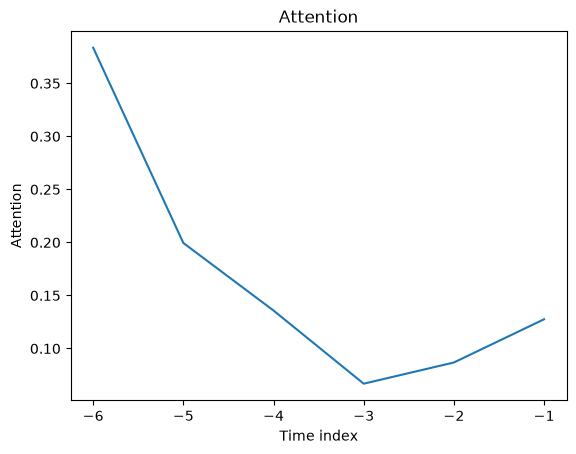

  - static_variables


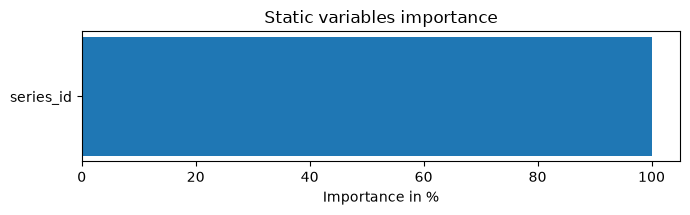

  - encoder_variables


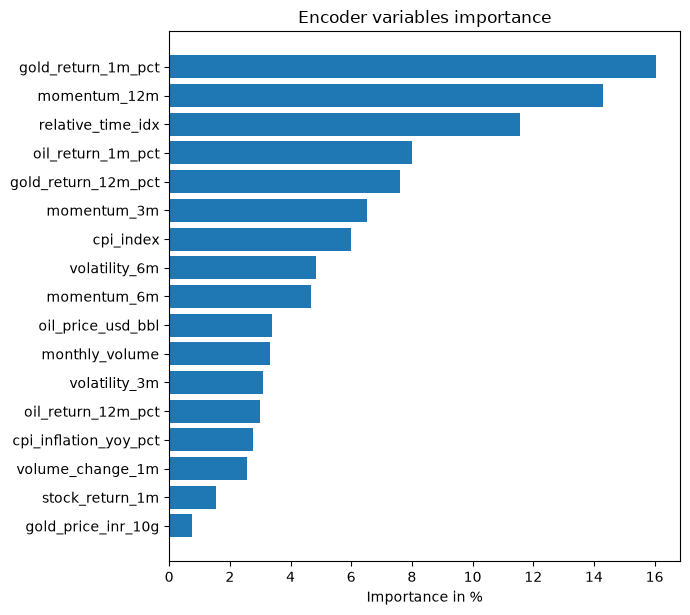

  - decoder_variables


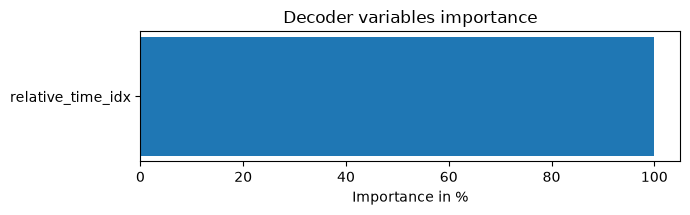

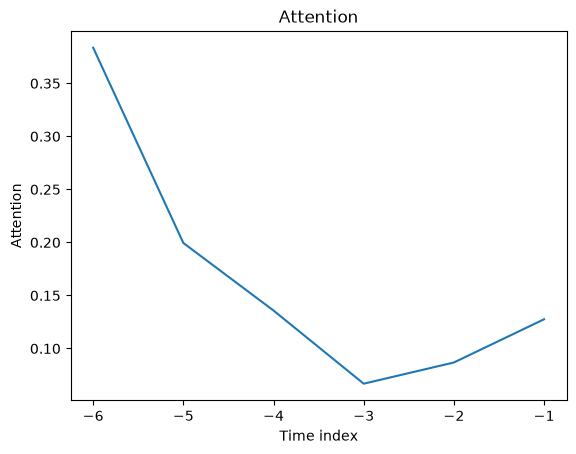

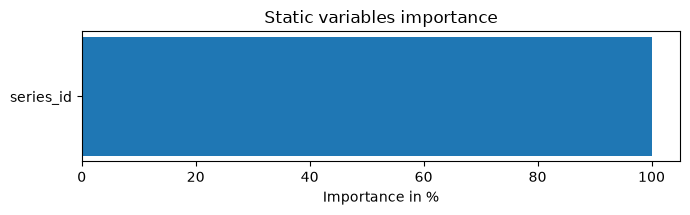

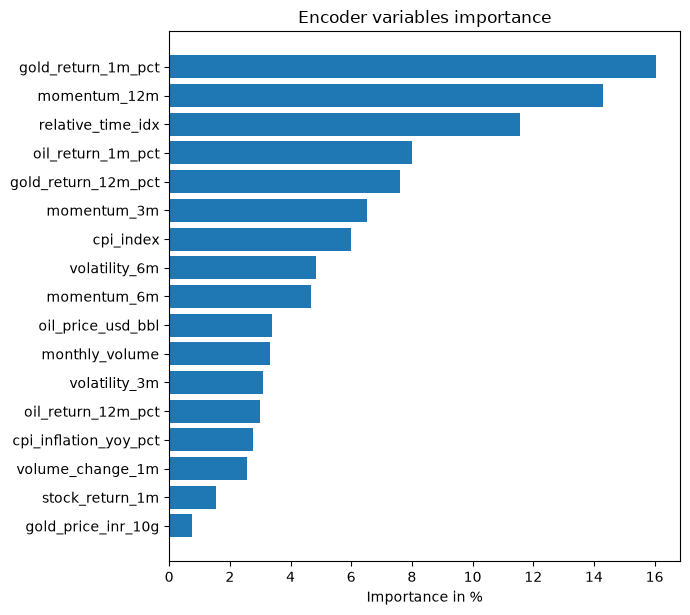

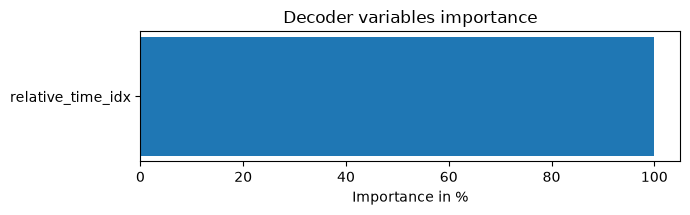

In [196]:
# Generate TFT-native feature importance and attention plots

raw_validation_predictions = tft.predict(
    val_dataloader,
    mode='raw',
    return_x=True,
    trainer_kwargs={'accelerator': TRAINER_ACCELERATOR, 'devices': 1},
)

interpretation = tft.interpret_output(
    raw_validation_predictions.output,
    reduction='sum',
)
interpretation_figures = tft.plot_interpretation(interpretation)

print('TFT interpretation plots:')
for plot_name, figure in interpretation_figures.items():
    print(f'  - {plot_name}')
    display(figure)


In [197]:
def plot_company_predictions(company_name):
    company_df = test_eval[test_eval['symbol'] == company_name].sort_values('date').copy()
    if company_df.empty:
        raise ValueError(f'Company not found: {company_name}')

    mae = mean_absolute_error(company_df['actual'], company_df['predicted'])
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=company_df['date'],
        y=company_df['actual'],
        mode='lines+markers',
        name='Actual',
        line=dict(color='royalblue', width=2)
    ))
    fig.add_trace(go.Scatter(
        x=company_df['date'],
        y=company_df['predicted'],
        mode='lines+markers',
        name='Predicted',
        line=dict(color='firebrick', width=2)
    ))
    fig.update_layout(
        title=f'{company_name} actual vs predicted returns | MAE={mae:.4f}',
        xaxis_title='Date',
        yaxis_title='Return (%)',
        template='plotly_white',
        height=500,
    )
    return fig


def plot_top_companies(top_n=5):
    summary = (
        test_eval.groupby('symbol')
        .apply(lambda g: mean_absolute_error(g['actual'], g['predicted']))
        .rename('mae')
        .sort_values()
        .head(top_n)
    )
    print('Top companies by MAE:')
    print(summary)
    for company in summary.index:
        plot_company_predictions(company).show()
    return summary

# Example usage:
# plot_company_predictions('RELIANCE')
# plot_top_companies(5)

In [198]:
# Align each forecast with its decoder date and company. The test dataframe
# contains raw rows, while the dataset returns one row per forecast window.
test_metadata = test[['series_id', 'time_idx', 'symbol', 'date']].copy()
test_eval = prediction_indices.merge(
    test_metadata,
    on=['series_id', 'time_idx'],
    how='left',
    validate='one_to_one',
)
test_eval['actual'] = actuals
test_eval['predicted'] = predictions
test_eval['abs_error'] = (test_eval['actual'] - test_eval['predicted']).abs()
test_eval['date'] = pd.to_datetime(test_eval['date'])

if test_eval[['symbol', 'date']].isna().any().any():
    raise ValueError('Some predictions could not be matched to test metadata')

available_companies = sorted(test_eval['symbol'].dropna().unique())
print('Available companies:')
for company in available_companies:
    print(f'  - {company}')

Available companies:
  - AARTIIND
  - AAVAS
  - ABB
  - ABBOTINDIA
  - ABDL
  - ABREL
  - ABSLAMC
  - ACC
  - ACI
  - ACMESOLAR
  - ADANIENT
  - ADANIPORTS
  - AFCONS
  - AFFLE
  - AJANTPHARM
  - ALKEM
  - AMBUJACEM
  - ANUP
  - APARINDS
  - APOLLOHOSP
  - APOLLOTYRE
  - ARVIND
  - ASAHIINDIA
  - ASHIANA
  - ASHOKLEY
  - ASIANPAINT
  - ASTEC
  - ASTERDM
  - ASTRAMICRO
  - ASTRAZEN
  - AUBANK
  - AUROPHARMA
  - AUTOAXLES
  - AVALON
  - AWL
  - AXISBANK
  - BAJAJ-AUTO
  - BAJAJCON
  - BAJAJELEC
  - BAJAJFINSV
  - BAJEL
  - BAJFINANCE
  - BALKRISIND
  - BALRAMCHIN
  - BANDHANBNK
  - BANKBARODA
  - BANKINDIA
  - BAYERCROP
  - BDL
  - BEL
  - BEML
  - BHARATFORG
  - BHARTIARTL
  - BHARTIHEXA
  - BHEL
  - BIOCON
  - BIRLACORPN
  - BLUEDART
  - BLUESTARCO
  - BOSCHLTD
  - BPCL
  - BRIGADE
  - BRITANNIA
  - BSE
  - BSOFT
  - CAMPUS
  - CAMS
  - CANFINHOME
  - CARBORUNIV
  - CARERATING
  - CASTROLIND
  - CDSL
  - CENTURYPLY
  - CESC
  - CHALET
  - CHAMBLFERT
  - CHOLAFIN
  - CIEINDIA
  - CIPLA


In [199]:
plot_company_predictions('ICICIBANK')

In [200]:
plot_company_predictions('INDIGO')

In [201]:
plot_company_predictions('JSWSTEEL')

In [202]:
plot_company_predictions('MARUTI')

In [203]:
plot_company_predictions('RELIANCE')

In [204]:
print(f'Model workflow completed for v{MODEL_VERSION}')

Model workflow completed for v10
